In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Entorno configurado correctamente.")

Entorno configurado correctamente.


In [6]:
# Carga y muestra los primeros datos
# CORRECTO: al estar en la carpeta lab3, no necesitas repetir el nombre de la carpeta
df = pd.read_csv('network_traffic.csv')

print("Primeras 5 filas del dataset:")
display(df.head())

Primeras 5 filas del dataset:


,timestamp,src_ip,dst_ip,dst_port,protocol,bytes_sent,bytes_recv,duration_sec,packets,label
0,2024-05-26 04:28:31,10.0.2.118,201.250.32.133,21,TCP,15310,45067,42.01,16,normal
1,2024-05-11 01:38:15,10.0.1.189,193.199.92.89,21,UDP,3692990,68116,55.35,2823,normal
2,2024-05-17 21:00:41,10.0.3.254,202.222.194.7,443,ICMP,23007,950555,6.64,18,normal
3,2024-05-09 18:30:38,10.0.1.254,152.183.142.33,25,TCP,467423,56148,3.12,656,normal
4,2024-05-27 17:50:29,10.0.3.87,64.39.138.32,3306,UDP,15355,18895,16.82,23,normal


In [7]:
import os
print("Tu directorio de trabajo actual es:", os.getcwd())
print("¿Existe el archivo aquí?", os.path.exists('network_traffic.csv'))

Tu directorio de trabajo actual es: E:\examen-practico-huahuaccapa\lab3
¿Existe el archivo aquí? True


Modelo entrenado exitosamente.

Reporte de Clasificación:
              precision    recall  f1-score   support

          -1       0.67      0.67      0.67       500
           1       0.98      0.98      0.98      9500

    accuracy                           0.97     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.97      0.97      0.97     10000



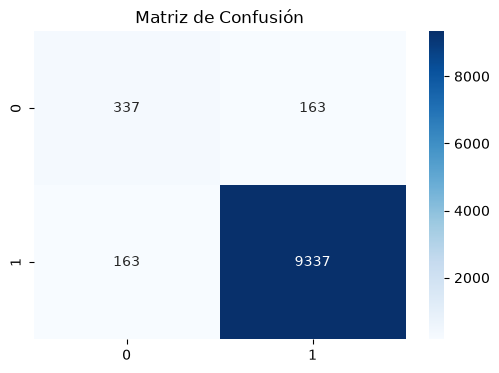

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

# Normalización
features = df.select_dtypes(include=['float64', 'int64']).drop(columns=['label'], errors='ignore')
scaler = StandardScaler()
df_scaled = scaler.fit_transform(features)

# Entrenamiento
model = IsolationForest(contamination=0.05, n_estimators=100, random_state=42)
model.fit(df_scaled)
print("Modelo entrenado exitosamente.")

# Predicciones
preds = model.predict(df_scaled)
y_true = df['label'].map({'normal': 1, 'anomaly': -1})

# Resultados
print("\nReporte de Clasificación:")
print(classification_report(y_true, preds))

# Gráfica de matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_true, preds), annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.show()

In [9]:
import joblib

# Guardar ambos objetos
joblib.dump(model, 'modelo_anomalias.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Modelo y Scaler exportados como .pkl")

Modelo y Scaler exportados como .pkl


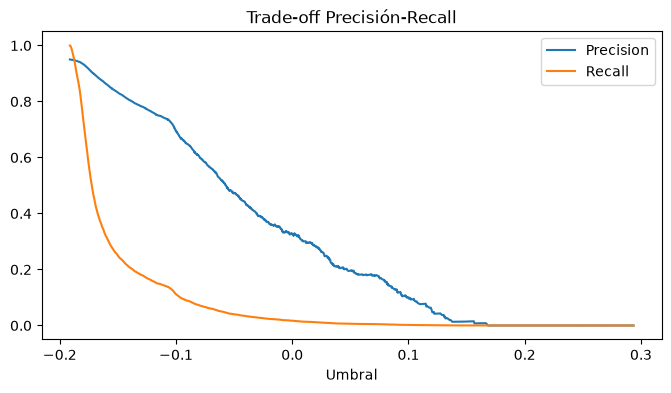

In [15]:
from sklearn.metrics import precision_recall_curve

# Obtener los scores de decisión (más negativo = más anómalo)
scores = model.decision_function(df_scaled)

precision, recall, thresholds = precision_recall_curve(y_true, -scores)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Umbral')
plt.legend()
plt.title('Trade-off Precisión-Recall')
plt.show()